# EDA — Predicting Irrigation Need (Kaggle S6E4)
**Author:** Tyler Wolf Williams (@tylerwolfwilliams2)  
**Competition:** https://www.kaggle.com/competitions/playground-series-s6e4

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

DATA_PATH = '../Homework 2/'

train = pd.read_csv(DATA_PATH + 'train.csv')
test  = pd.read_csv(DATA_PATH + 'test.csv')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)

Train shape: (630000, 21)
Test shape:  (270000, 20)


## 1. Basic Overview

In [2]:
train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [4]:
train.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


## 2. Missing Values

In [5]:
missing_train = train.isnull().sum()
missing_test  = test.isnull().sum()

print('=== Train missing values ===')
print(missing_train[missing_train > 0] if missing_train.any() else 'None')
print('\n=== Test missing values ===')
print(missing_test[missing_test > 0] if missing_test.any() else 'None')

=== Train missing values ===
None

=== Test missing values ===
None


## 3. Target Distribution

Class counts:
Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

Class percentages:
Irrigation_Need
Low       58.72
Medium    37.95
High       3.33
Name: proportion, dtype: float64


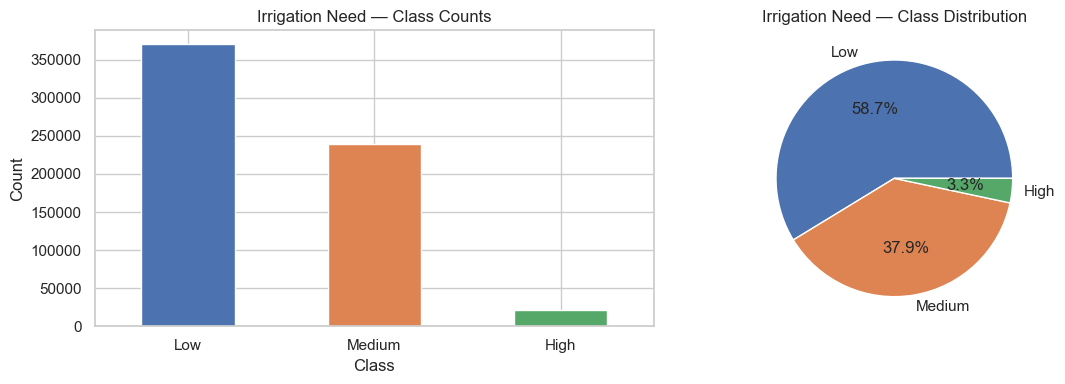

In [6]:
target_counts = train['Irrigation_Need'].value_counts()
target_pct    = train['Irrigation_Need'].value_counts(normalize=True) * 100

print('Class counts:')
print(target_counts)
print('\nClass percentages:')
print(target_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('Irrigation Need — Class Counts')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452', '#55A868'])
axes[1].set_title('Irrigation Need — Class Distribution')

plt.tight_layout()
plt.show()

## 4. Numerical Feature Distributions

In [7]:
num_cols = train.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in ['id']]
print('Numerical features:', num_cols)

Numerical features: ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']


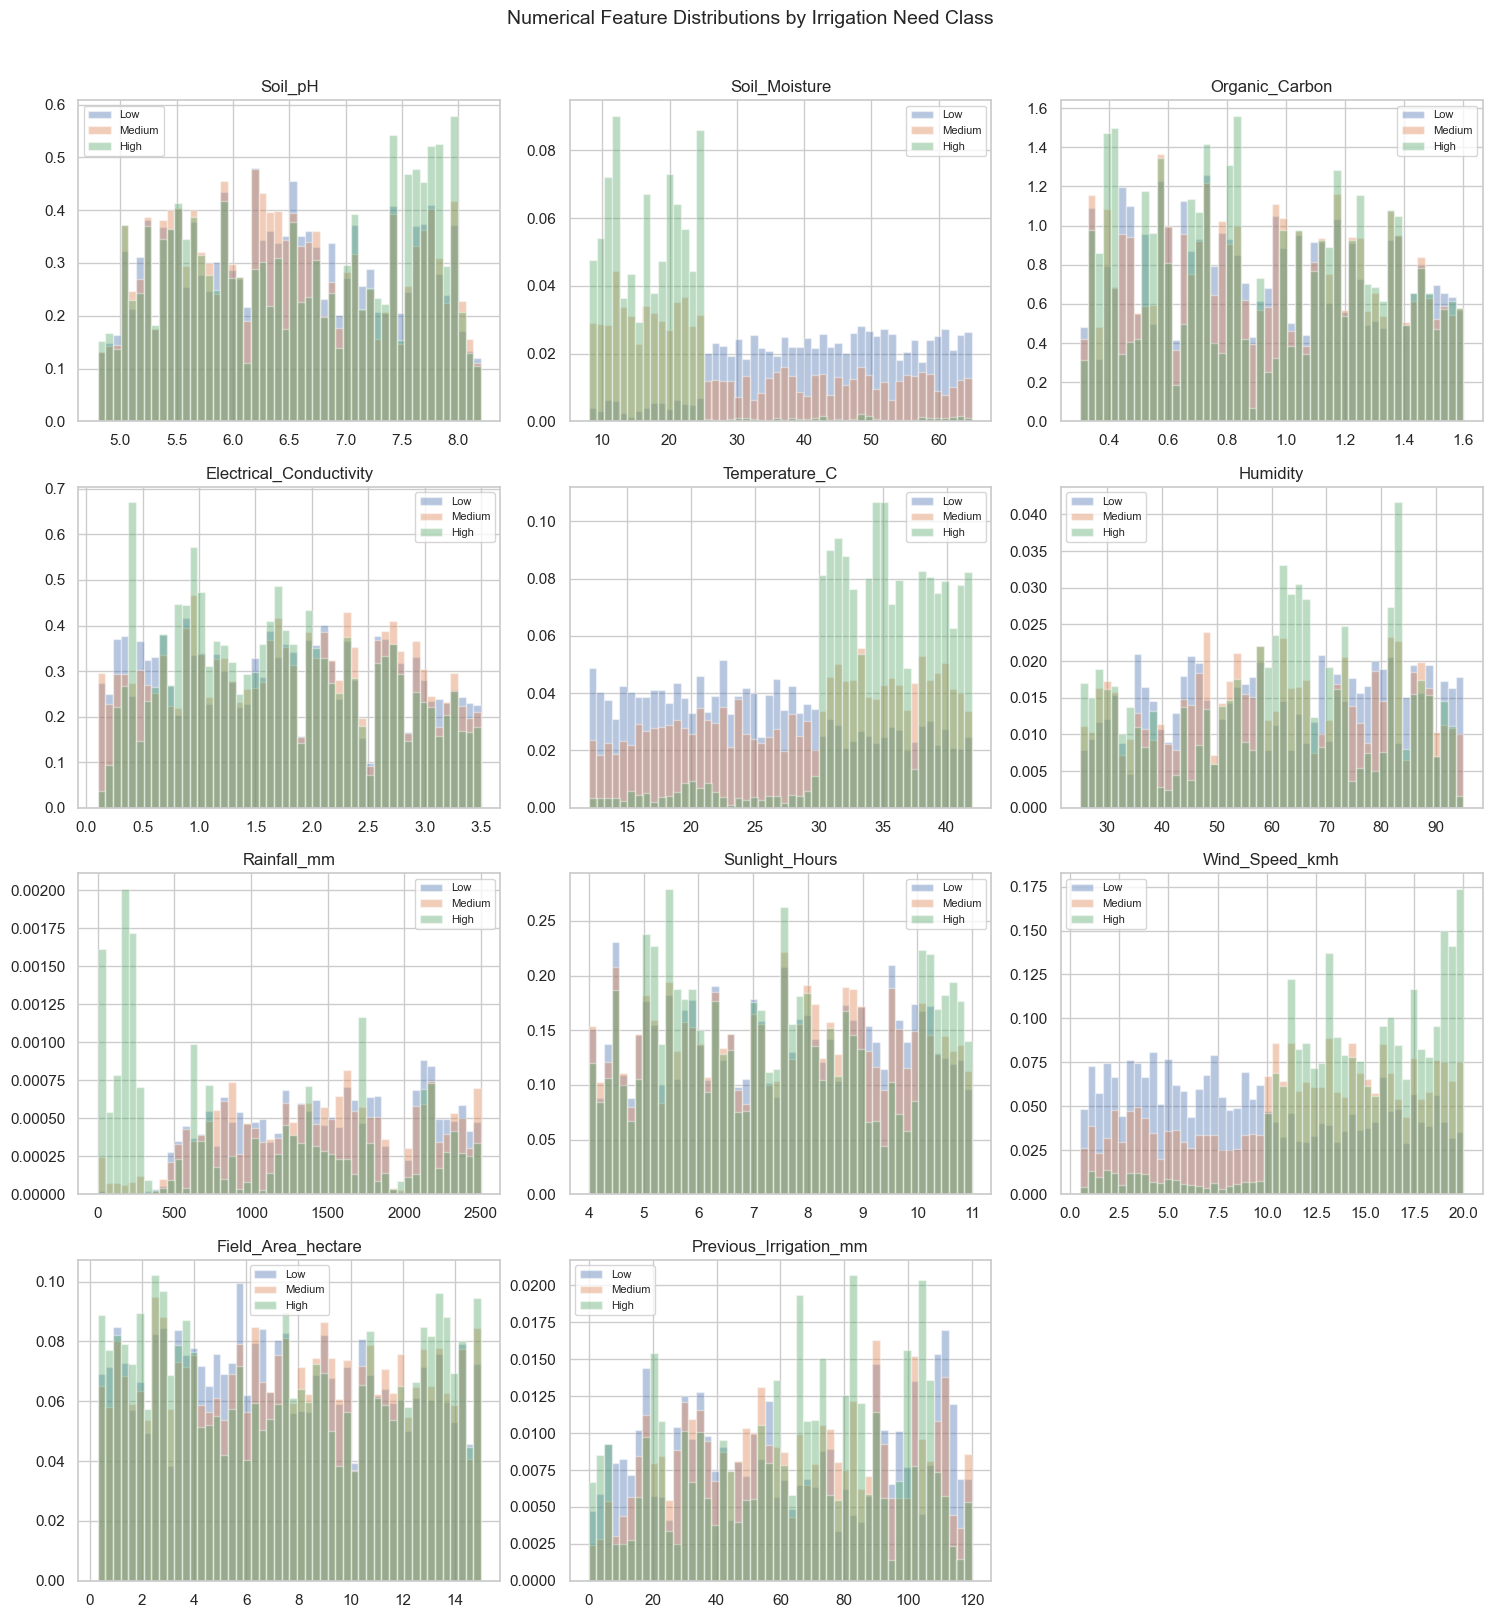

In [8]:
# KDE plots by target class — shows how well each feature separates classes
target_classes = train['Irrigation_Need'].unique()
palette = {'Low': '#4C72B0', 'Medium': '#DD8452', 'High': '#55A868'}

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for cls in target_classes:
        subset = train[train['Irrigation_Need'] == cls][col]
        color = palette.get(cls, 'gray')
        axes[i].hist(subset, bins=50, alpha=0.4, label=cls, color=color, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Irrigation Need Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

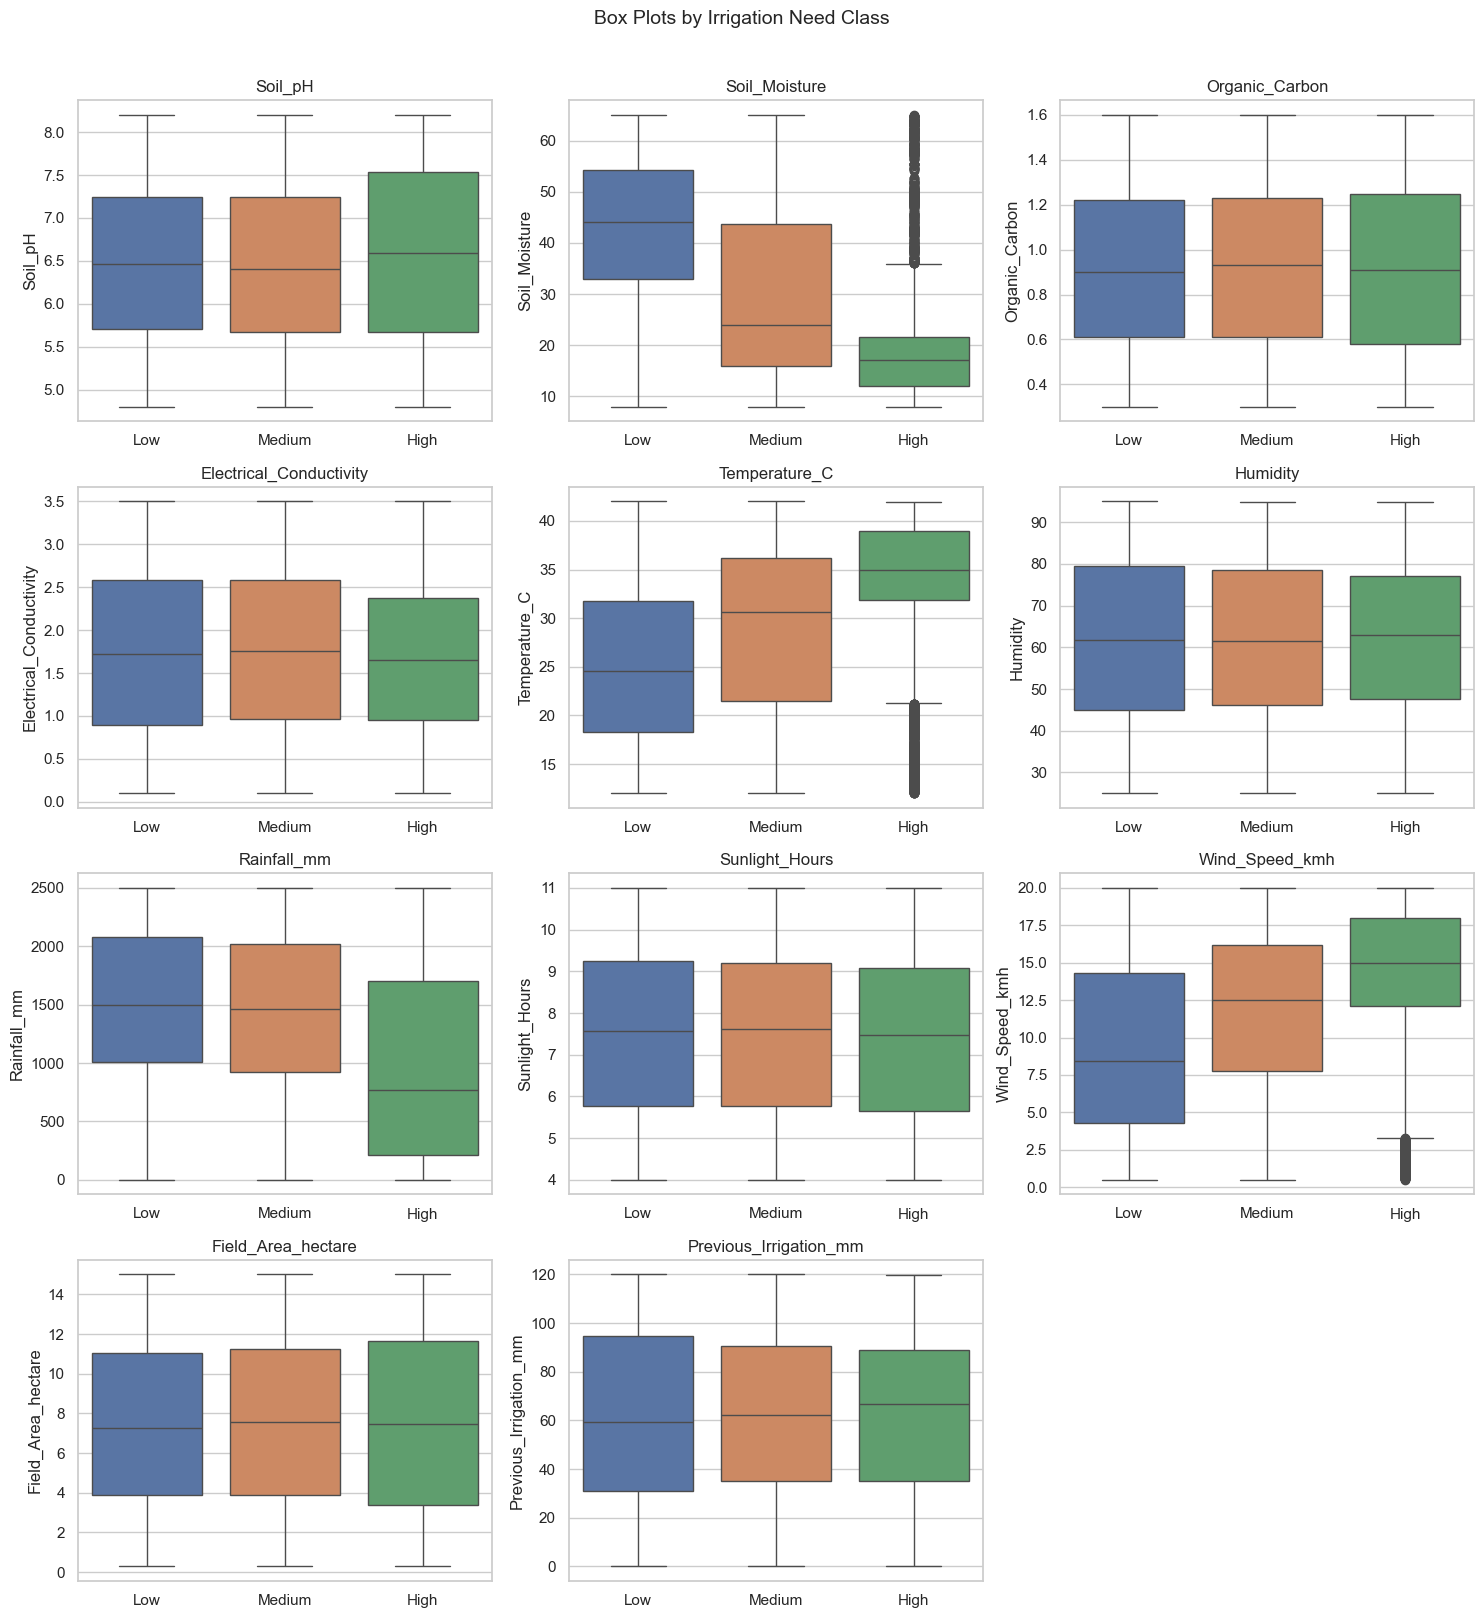

In [9]:
# Box plots — easier to see median/IQR differences
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    order = ['Low', 'Medium', 'High'] if 'High' in target_classes else sorted(target_classes)
    sns.boxplot(data=train, x='Irrigation_Need', y=col, ax=axes[i],
                order=order, palette=palette)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots by Irrigation Need Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Categorical Feature Analysis

In [10]:
cat_cols = train.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'Irrigation_Need']
print('Categorical features:', cat_cols)

for col in cat_cols:
    print(f'\n{col}: {train[col].nunique()} unique values → {train[col].unique()}')

Categorical features: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

Soil_Type: 4 unique values → ['Loamy' 'Clay' 'Sandy' 'Silt']

Crop_Type: 6 unique values → ['Sugarcane' 'Wheat' 'Rice' 'Potato' 'Cotton' 'Maize']

Crop_Growth_Stage: 4 unique values → ['Sowing' 'Vegetative' 'Flowering' 'Harvest']

Season: 3 unique values → ['Zaid' 'Kharif' 'Rabi']

Irrigation_Type: 4 unique values → ['Drip' 'Rainfed' 'Sprinkler' 'Canal']

Water_Source: 4 unique values → ['Rainwater' 'River' 'Reservoir' 'Groundwater']

Mulching_Used: 2 unique values → ['No' 'Yes']

Region: 5 unique values → ['East' 'South' 'North' 'West' 'Central']


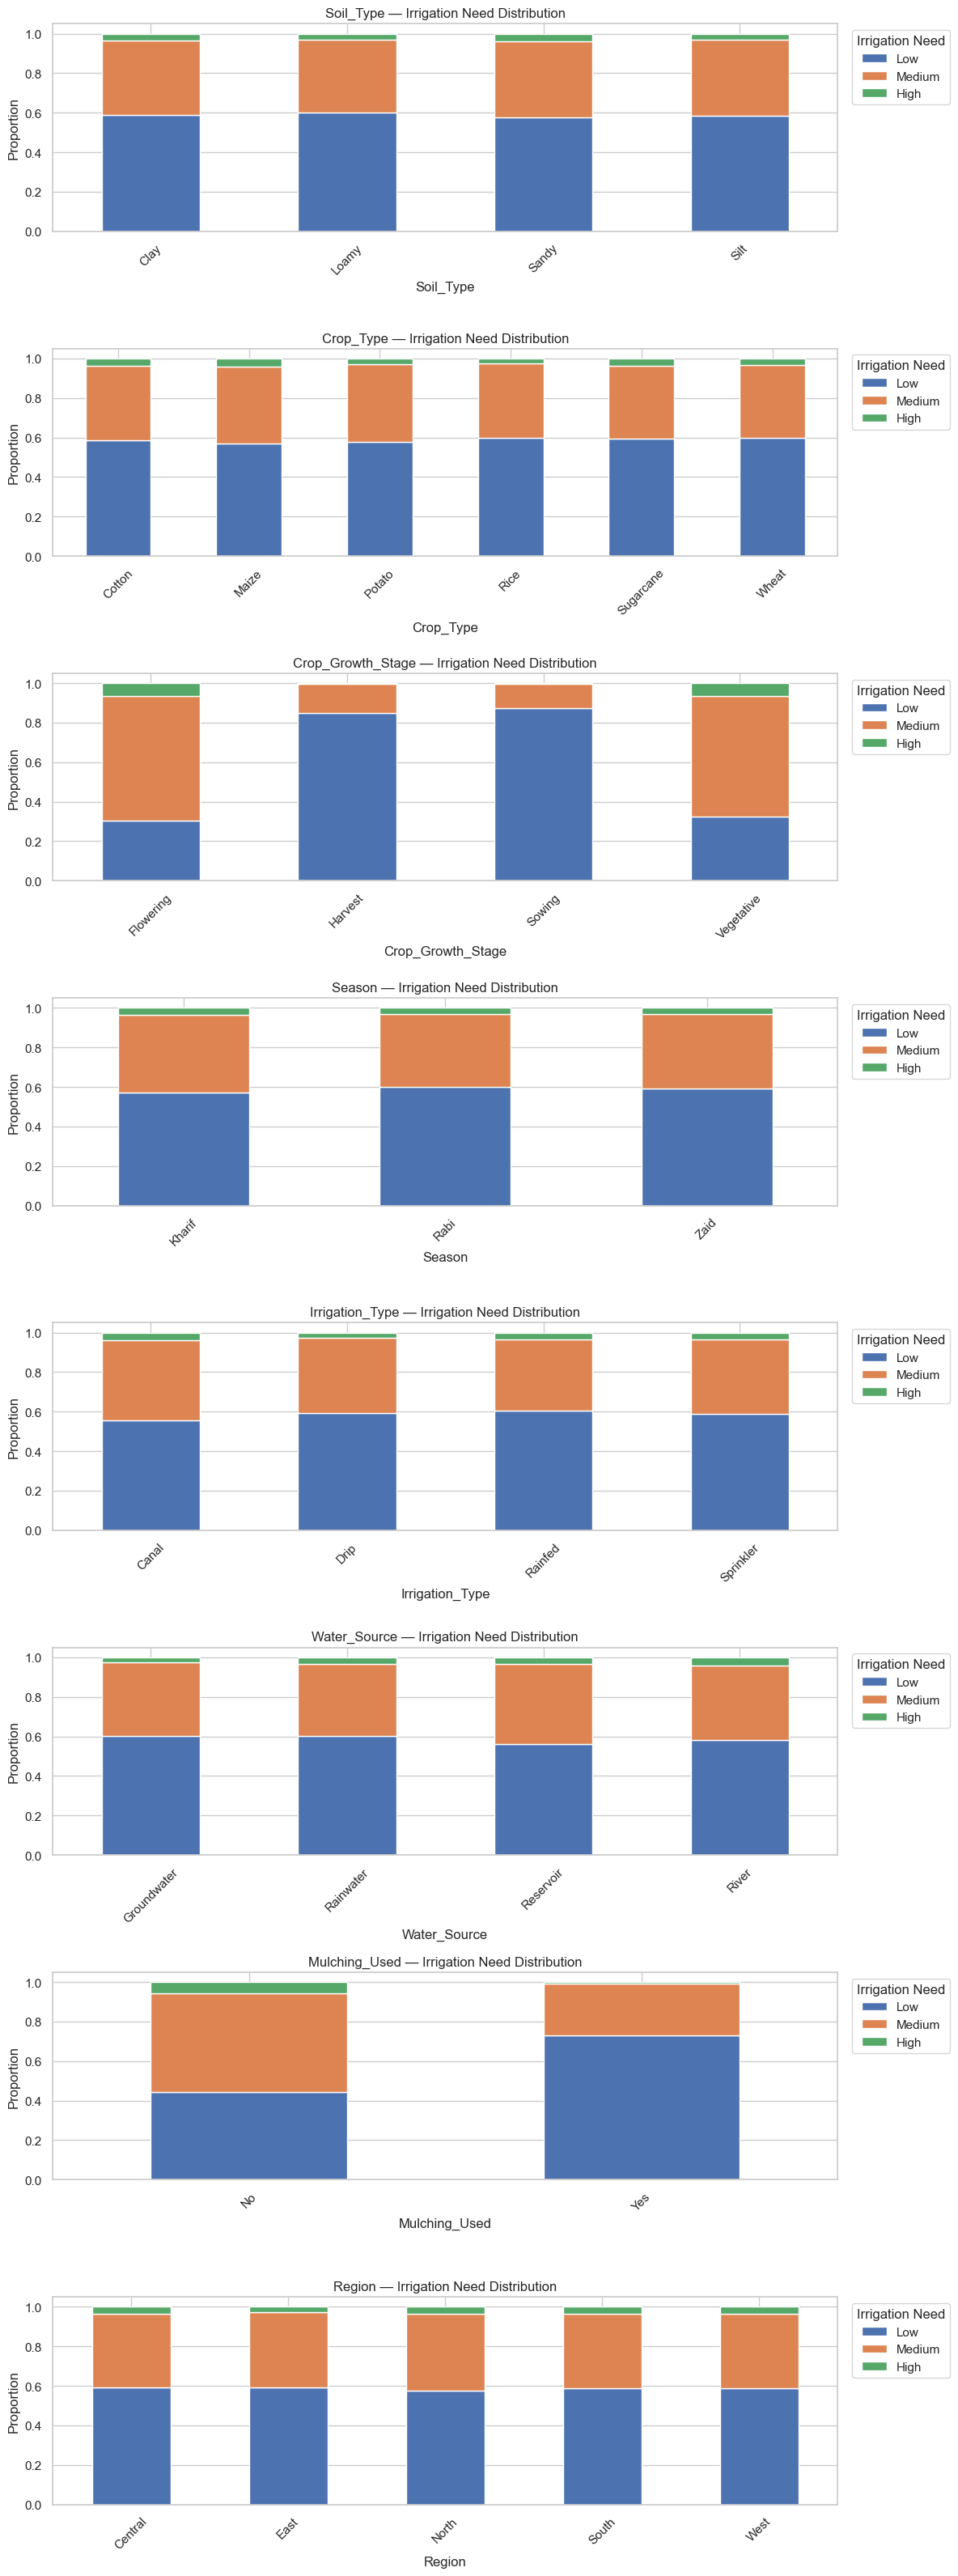

In [11]:
# Stacked bar chart: proportion of each target class within each category
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(12, len(cat_cols) * 4))
if len(cat_cols) == 1:
    axes = [axes]

order = ['Low', 'Medium', 'High'] if 'High' in train['Irrigation_Need'].values else sorted(train['Irrigation_Need'].unique())

for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(train[col], train['Irrigation_Need'], normalize='index')[order]
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=[palette.get(c, 'gray') for c in order])
    ax.set_title(f'{col} — Irrigation Need Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Proportion')
    ax.legend(title='Irrigation Need', bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Correlation Matrix (Numerical Features)

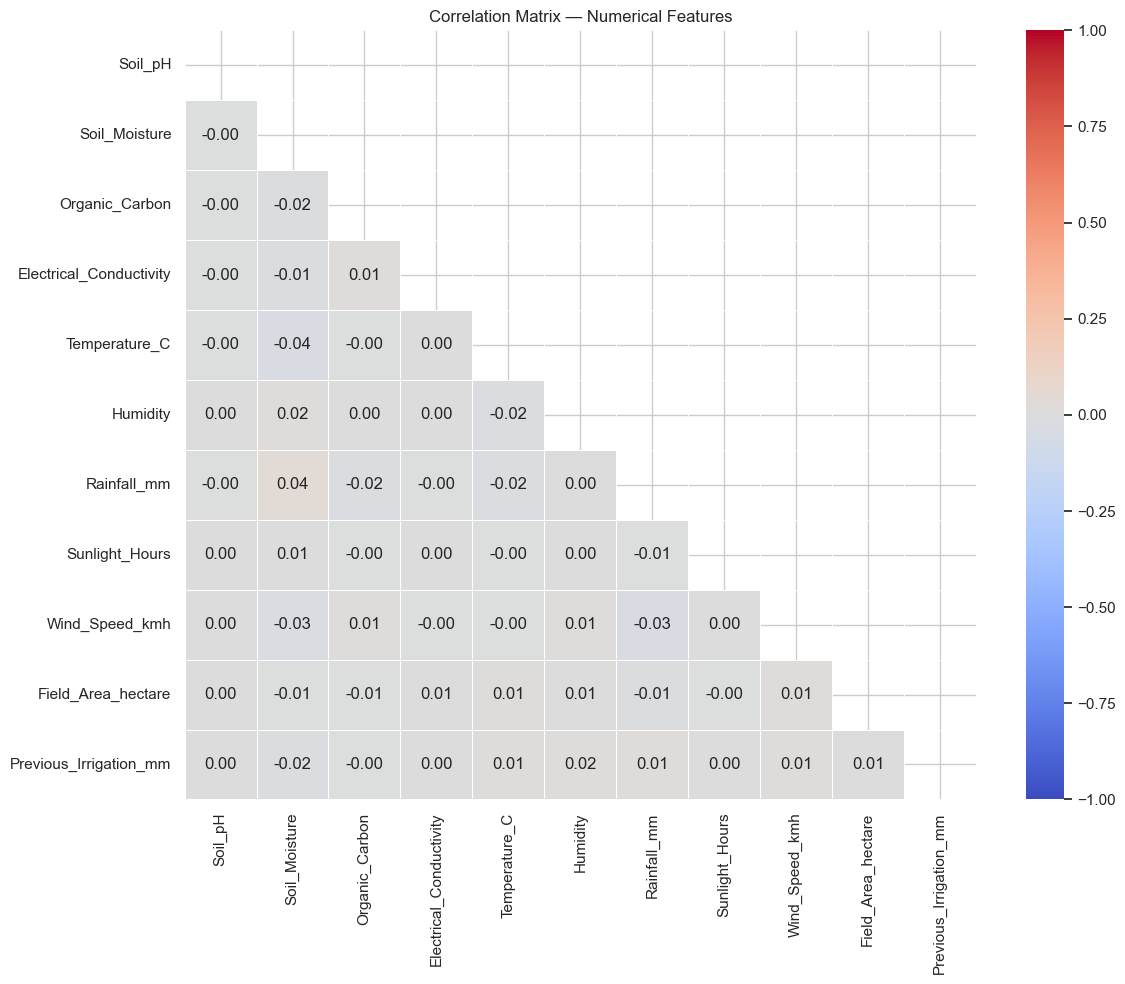

In [12]:
corr = train[num_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

## 7. Feature vs. Target Correlation (Point-Biserial / ANOVA)

In [13]:
from sklearn.preprocessing import LabelEncoder
from scipy import stats

le = LabelEncoder()
y_encoded = le.fit_transform(train['Irrigation_Need'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# One-way ANOVA F-statistic for each numerical feature vs target
anova_results = {}
for col in num_cols:
    groups = [train[train['Irrigation_Need'] == cls][col].values
              for cls in train['Irrigation_Need'].unique()]
    f_stat, p_val = stats.f_oneway(*groups)
    anova_results[col] = {'F_statistic': f_stat, 'p_value': p_val}

anova_df = pd.DataFrame(anova_results).T.sort_values('F_statistic', ascending=False)
print('\nANOVA F-statistics (higher = more discriminative):')
print(anova_df.round(4))

Label mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

ANOVA F-statistics (higher = more discriminative):
                         F_statistic  p_value
Soil_Moisture             82555.9179   0.0000
Wind_Speed_kmh            22514.0942   0.0000
Temperature_C             22043.7591   0.0000
Rainfall_mm                7241.6312   0.0000
Humidity                    172.2973   0.0000
Soil_pH                     158.2962   0.0000
Electrical_Conductivity     146.9581   0.0000
Previous_Irrigation_mm      137.6441   0.0000
Field_Area_hectare          130.1552   0.0000
Organic_Carbon               16.1679   0.0000
Sunlight_Hours                8.7403   0.0002


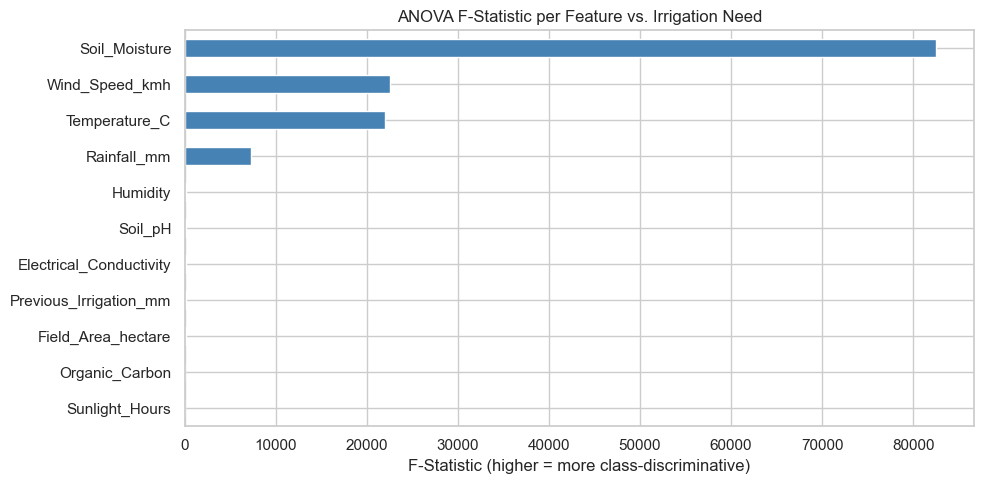

In [14]:
plt.figure(figsize=(10, 5))
anova_df['F_statistic'].plot(kind='barh', color='steelblue')
plt.title('ANOVA F-Statistic per Feature vs. Irrigation Need')
plt.xlabel('F-Statistic (higher = more class-discriminative)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Train vs. Test Distribution Check

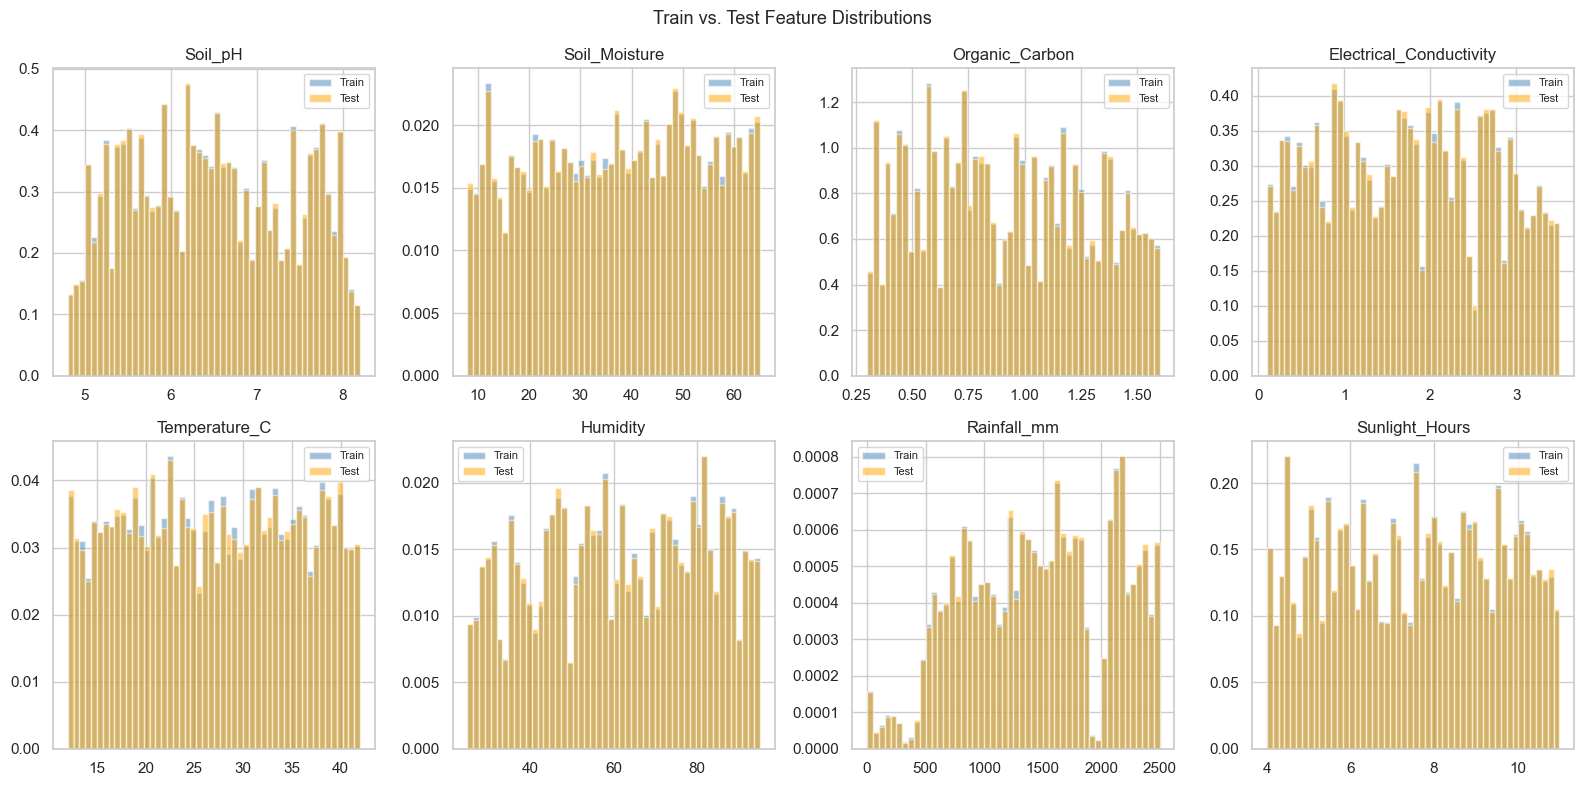

In [15]:
# Verify test set has same feature distributions as train (no covariate shift)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols[:8]):
    axes[i].hist(train[col], bins=50, alpha=0.5, label='Train', color='steelblue', density=True)
    axes[i].hist(test[col],  bins=50, alpha=0.5, label='Test',  color='orange',   density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Train vs. Test Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Key Insights Summary

1. **Target balance:** Imbalanced — Low: 369,917 (58.72%), Medium: 239,074 (37.95%), High: 21,009 (3.33%). The `High` class is severely underrepresented (~1/18th of `Low`). Consider class-weighting or oversampling.

2. **Top numerical features (ANOVA F-statistic):**
   - `Soil_Moisture` dominates by a wide margin (F = 82,556) — by far the most class-discriminative feature.
   - `Wind_Speed_kmh` (F = 22,514) and `Temperature_C` (F = 22,044) are second-tier but still highly informative.
   - `Rainfall_mm` (F = 7,242) is strong. All others (Humidity, Soil_pH, EC, etc.) are statistically significant but weaker.
   - `Sunlight_Hours` is the weakest numerical feature (F = 8.7).

3. **Categorical features:** 8 categorical variables — `Soil_Type` (4), `Crop_Type` (6), `Crop_Growth_Stage` (4), `Season` (3), `Irrigation_Type` (4), `Water_Source` (4), `Mulching_Used` (2), `Region` (5).

4. **Potential leakage concern:** `Irrigation_Type` and `Water_Source` are likely downstream of the label — test model performance both with and without these features.

5. **Train/test distribution:** No covariate shift detected — train and test feature distributions appear well-aligned across all 8 plotted numerical features.

6. **Missing values:** None — train (630,000 rows) and test (270,000 rows) are both fully populated across all 20 features.
